/Users/nathankutz/anaconda3/lib/python3.11/site-packages/pydmd/bopdmd.py:751: UserWarning: Initial trial of Optimized DMD failed to converge. Consider re-adjusting your variable projection parameters with the varpro_opts_dict and consider setting verbose=True.
  warnings.warn(msg)
/Users/nathankutz/anaconda3/lib/python3.11/site-packages/pydmd/plotter.py:673: RuntimeWarning: divide by zero encountered in log
  eigs = np.log(lead_eigs)


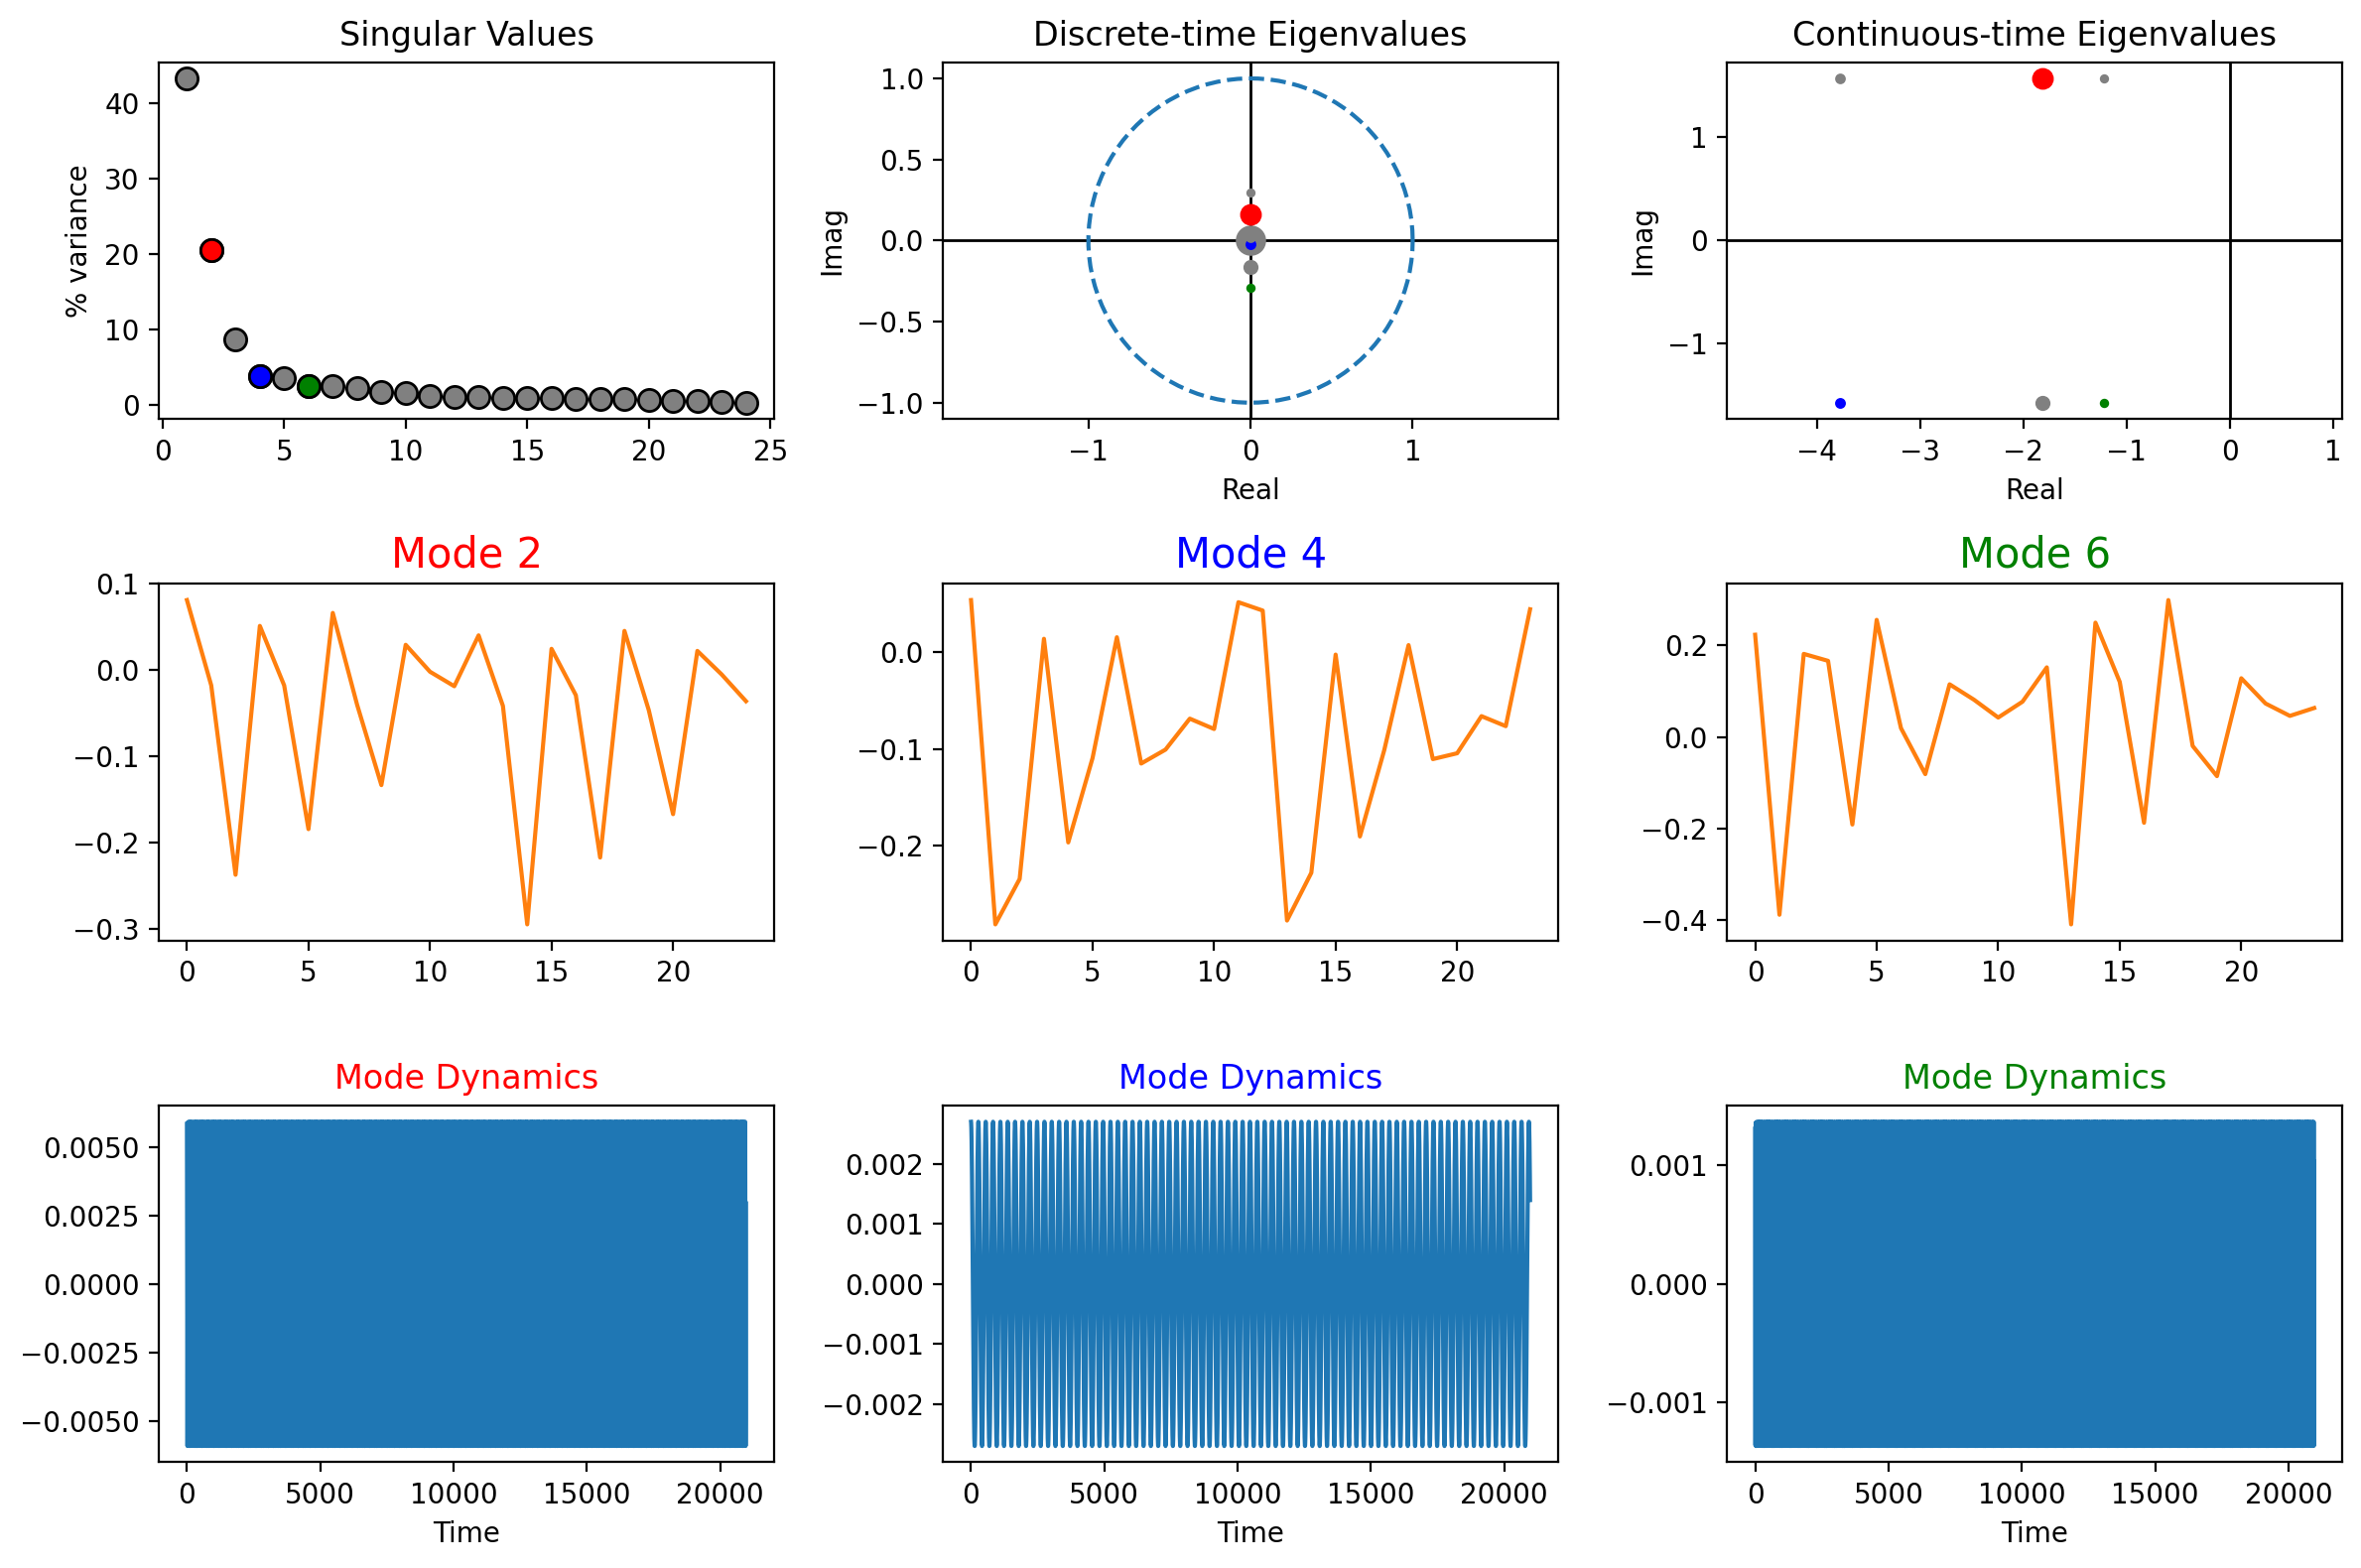

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from pydmd import DMD
from pydmd.bopdmd import BOPDMD
from pydmd.plotter import plot_eigs
from pydmd.plotter import plot_summary
from pydmd.preprocessing.hankel import hankel_preprocessing

X = np.load('toothless_9m_no_obstacle.npy')
[m,n]=X.shape
#t=X[0,0:200]
t=np.arange(0,n,1)
U=X[1:,:]
U = U - np.mean(U)

delay_optdmd = hankel_preprocessing(BOPDMD(svd_rank=7, num_trials=0, eig_constraints={"imag", "conjugate_pairs"}), d=2)
delay_optdmd.fit(U, t=t[1:])
plot_summary(delay_optdmd, index_modes=[1,3,5], order='F') # pick correct modes



(0.0, 2000.0)

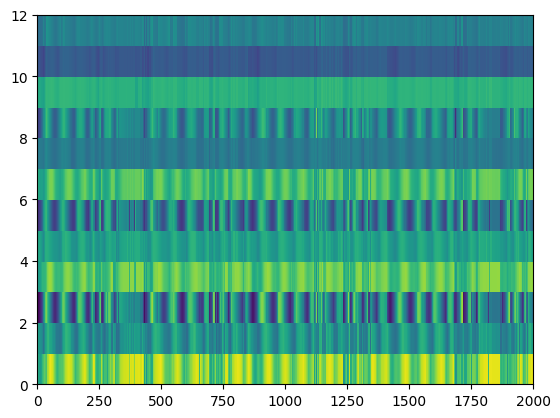

In [2]:
plt.pcolor(U)
plt.xlim(0,2000)


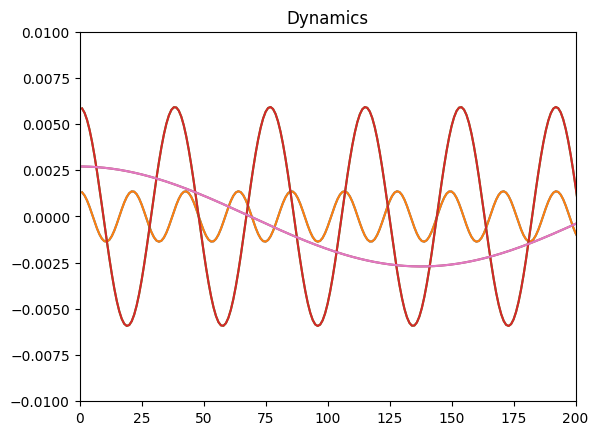

In [3]:
# pull out time dynamics
for dynamic in delay_optdmd.dynamics:
    plt.plot(t[1:], dynamic.real)
    plt.title("Dynamics")
    plt.xlim(0,200)
    plt.ylim(-0.01,0.01)
plt.show()

In [4]:
# Get modes
Psi = delay_optdmd.modes

#Get eigenvalues:
Lambda = delay_optdmd.eigs

#The b_n
bn = delay_optdmd.amplitudes

print(np.imag(Lambda))
print(bn)

[ 0.29422788 -0.29422788  0.163562   -0.163562    0.          0.02282285
 -0.02282285]
[0.00136657 0.00136657 0.00592524 0.00592524 0.84652901 0.00270477
 0.00270477]


<StemContainer object of 3 artists>

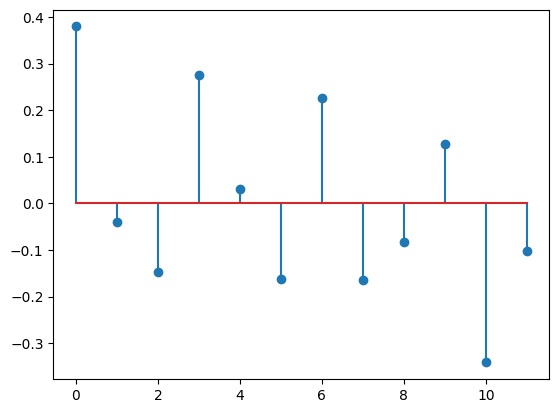

In [5]:
Psi.shape
Psi_real = np.real(Psi[:12,:])

plt.stem(Psi_real[:,4])
#plt.stem(Psi_real[:,1])



In [6]:
U.shape

(12, 20969)

In [7]:
Psi_real.shape

(12, 7)

In [8]:
proj = np.matmul((Psi_real.T),U)

In [9]:
proj.shape

(7, 20969)

(0.0, 200.0)

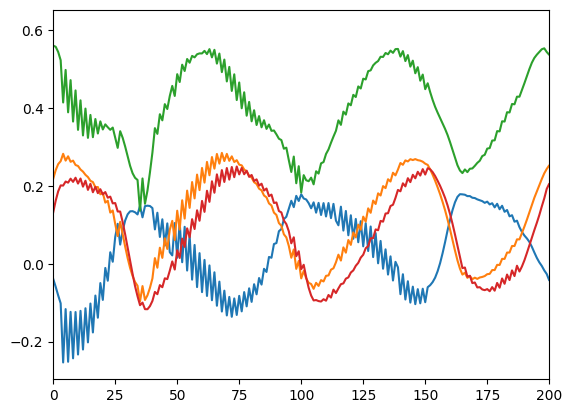

In [10]:
plt.plot(proj[0,:])
plt.plot(proj[2,:])
plt.plot(proj[4,:])
plt.plot(proj[5,:])
plt.xlim(0,200)


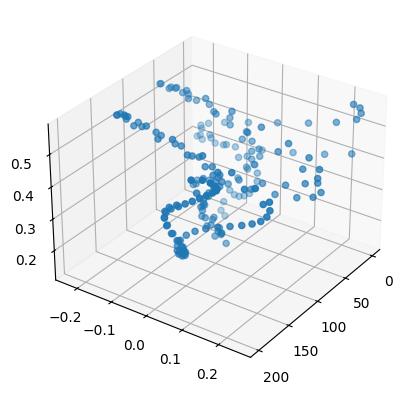

In [16]:
from mpl_toolkits.mplot3d import Axes3D


fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

x1 = proj[0,:200]*bn[0]
x2 = proj[2,:200]*bn[2]
x3 = proj[4,:200]*bn[4]
x4 = proj[5,:200]*bn[5]
ts = t[:200]

Lambdai=np.imag(Lambda)
y1 = x1*np.cos(Lambdai[0]*ts)
y2 = x2*np.cos(Lambdai[2]*ts)
y3 = x3*np.cos(Lambdai[4]*ts)
y4 = x4*np.cos(Lambdai[5]*ts)

# Plot the data points
ax.scatter(ts, y2, y3)
ax.view_init(elev=30, azim=35)  # Adjust the angles as needed



Forecasting


In [ ]:
avedt=np.average(dt)
time_forecast = np.arange(0.3, 3 + avedt, avedt)
#forecast_mean, forecast_variance = delay_optdmd.forecast(time_forecast)
forecast_mean = delay_optdmd.forecast(time_forecast)
